# Q13.
```{admonition}
:class: note
In this exercise you will create some simulated data and will fit simple linear regression models to it.

In [1]:
import numpy as np
import statsmodels.api as sm
from IPython.display import display, Latex
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

## (a)
```{admonition}
:class: note
Using the `normal()` method of your random number generator, create a vector `x` containing 100 observations drawn from $N(0,1)$.

In [3]:
rng = np.random.default_rng(1728)
x = rng.normal(size = 100)

## (b)
```{admonition}
:class: note
Using the `normal()` method, create a vector `eps` containing 100 observations drawn from $N(0,0.25)$.

In [4]:
eps = rng.normal(size = 100, scale = 0.25)

## (c)
```{admonition}
:class: note
Using `x` and `eps`, generate a vector `y` according to
$$
Y = -1+0.5X+\varepsilon.
$$

What is the length of the vector `y`? What are the values of $\beta_{0}$ and $\beta_{1}$ in this linear model?

In [5]:
y = -1+0.5*x+eps
length_y = np.linalg.norm(y)
display(Latex(fr'The length of y is {length_y:.2f}. We also have $\beta_{{0}}$ = -1 and $\beta_{{1}}$ = 0.5'))

<IPython.core.display.Latex object>

## (d)
```{admonition}
:class: note
Create a scatter plott displaying the relationship between `x` and `y`.

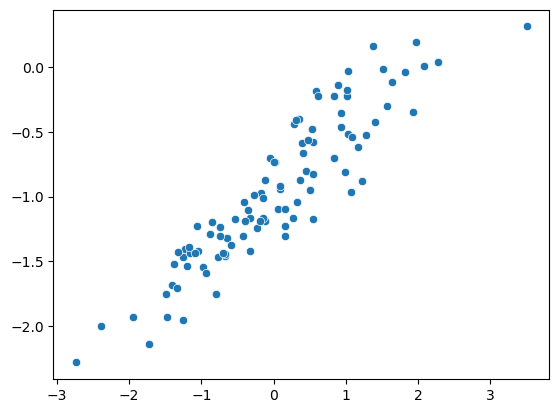

In [6]:
sns.scatterplot(x=x,y=y);

## (e)
```{admonition}
:class: note
Fit a least squares linear model to predict `y` using `x`. How do $\hat{\beta_{0}}$ and $\hat{\beta_{1}}$ compare to $\beta_{0}$ and $\beta_{1}$?

In [7]:
model1 = sm.OLS(y,sm.add_constant(x)).fit()
b0, b1 = model1.params
display(Latex(r'The values $\hat{{\beta}}_{{0}} = {:.2f}$ compared to $\beta_{{0}} = -1$ and $\hat{{\beta}}_{{1}} = {:.2f}$ compared to $\beta_{{1}} = 0.5$'.format(b0,b1)))

<IPython.core.display.Latex object>

## (f)
```{admonition}
:class: note
Display the least squares line on the scatterplot obtained in (d). Draw the population regrssion line on the plot in a different color. Use the `legend()` method of the axes to create an appropriate legend.

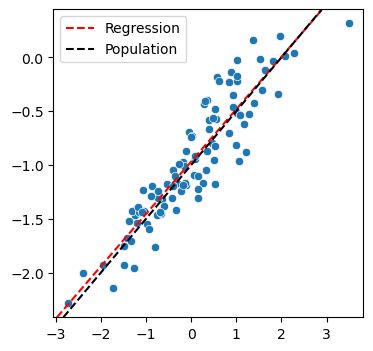

In [8]:
fig, ax = subplots(figsize = (4,4))
sns.scatterplot(x=x,y=y,ax=ax)
ax.axline((0,b0),slope = b1,color='r',linestyle='--',label='Regression')
ax.axline((0,-1),slope = 0.5,color='k',linestyle='--',label='Population')
ax.legend();


In [9]:
model1.rsquared

np.float64(0.8403092538041773)

## (g)
```{admonition}
:class: note
Now fit a polynomial regression model that predicts `y` using `x` and `x^2`. Is there evidence that the quadratic term improves the model fit?

In [10]:
model2 = sm.OLS(y,sm.add_constant(np.column_stack([x,x**2]))).fit()
c0, c1, c2 = model2.params

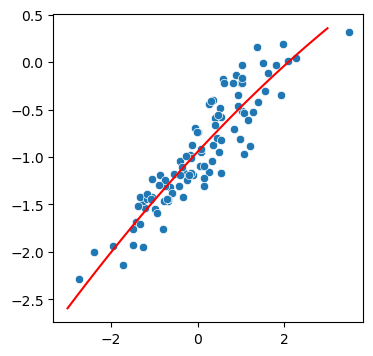

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [11]:
fig, ax = subplots(figsize = (4,4))
sns.scatterplot(x=x,y=y,ax=ax)
xs = np.linspace(-3,3,100)
ys = c0+c1*xs+c2*xs**2
plt.plot(xs,ys,'r')
plt.show()

display(Latex('The $r^2$ value of the linear model is {:.2f} and the mean squared error is {:.2f}'.format(model1.rsquared, model1.mse_model)))
display(Latex('The $r^2$ value of the quadratic model is {:.2f} and the mean squared error is {:.2f}'.format(model2.rsquared, model2.mse_model)))

## (h)
```{admonition}
:class: note
Repeat (a)-(f) after modifying the data generation process in such a way that there is *less* noise in the data.

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

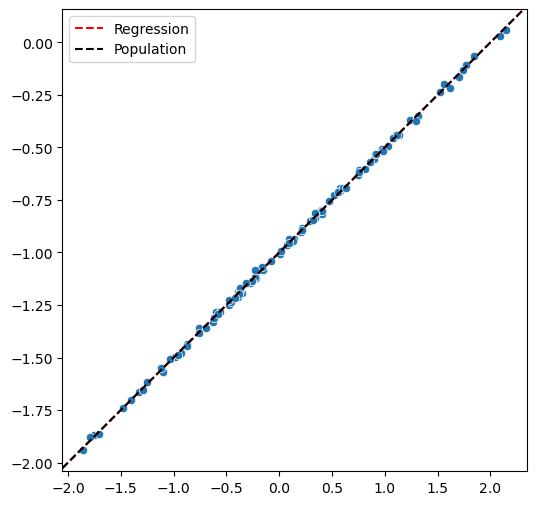

In [12]:
x2 = rng.normal(size = 100)
eps2 = rng.normal(size = 100, scale = 0.01)
y2 = -1+0.5*x2+eps2
length_y2 = np.linalg.norm(y2)

display(Latex(fr'The length of $y$ is {length_y2:.2f}. We also have $\beta_{{0}} = -1$ and $\beta_{{1}}= 0.5$'))
model3 = sm.OLS(y2,sm.add_constant(x2)).fit()
d0, d1 = model3.params

display(Latex(r'The values $\hat{{\beta}}_{{0}} = {:.4f}$ compared to $\beta_{{0}} = -1$ and $\hat{{\beta}}_{{1}} = {:.4f}$ compared to $\beta_{{1}} = 0.5$'.format(d0,d1)))

fig, ax = subplots(figsize = (6,6))
sns.scatterplot(x=x2,y=y2,ax=ax)
ax.axline((0,d0),slope = d1,color='r',linestyle='--',label='Regression')
ax.axline((0,-1),slope = 0.5,color='k',linestyle='--',label='Population')
ax.legend();

In [13]:
model3.rsquared

np.float64(0.9994534193781411)

## (i)
```{admonition}
:class: note
Repeat (a)-(f) after modifying the data generation process in such a way that there is *more* noise in the data.

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

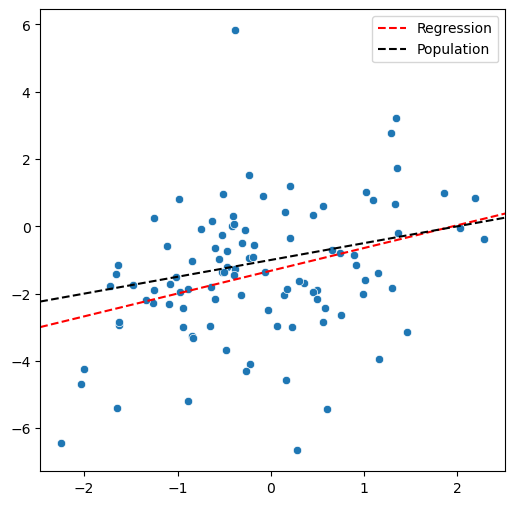

In [17]:
x3 = rng.normal(size = 100)
eps3 = rng.normal(size = 100, scale = 2)
y3 = -1+0.5*x3+eps3
length_y3 = np.linalg.norm(y3)

display(Latex(fr'The length of $y$ is {length_y3:.2f}. We also have $\beta_{{0}} = -1$ and $\beta_{{1}}= 0.5$'))
model4 = sm.OLS(y3,sm.add_constant(x3)).fit()
e0, e1 = model4.params

display(Latex(r'The values $\hat{{\beta}}_{{0}} = {:.4f}$ compared to $\beta_{{0}} = -1$ and $\hat{{\beta}}_{{1}} = {:.4f}$ compared to $\beta_{{1}} = 0.5$'.format(e0,e1)))

fig, ax = subplots(figsize = (6,6))
sns.scatterplot(x=x3,y=y3,ax=ax)
ax.axline((0,e0),slope = e1,color='r',linestyle='--',label='Regression')
ax.axline((0,-1),slope = 0.5,color='k',linestyle='--',label='Population')
ax.legend();

In [15]:
model4.rsquared

np.float64(0.05094679543443004)

(j) What are the confidence intervals for $\beta_{0}$ and $\beta_{1}$ based on the original data set, the noisier data set, and the less noisy data set?

In [16]:
for i,model in enumerate([model1,model3,model4]):
    b0_left, b0_right, b1_left, b1_right = model.conf_int().flatten()
    display(Latex(f'The confidence intervals for linear model {i} are $\\beta_{{0}}: ({b0_left:.4f},{b0_right:.4f})$ and $\\beta_{{1}}: ({b1_left:.4f},{b1_right:.4f})$'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>